# Heart Disease Prediction — End-to-End Machine Learning Project

### Goal
Build a clean, reproducible machine-learning workflow for predicting `HeartDisease` from the Heart Disease dataset.

### What this notebook emphasizes
1. **Data understanding and intuition**
2. **Data quality and leakage prevention**
3. **Hypothesis-driven EDA**
4. **Feature engineering**
5. **Feature selection / information value**
6. **Baseline vs engineered-feature experiments**
7. **Cross-validation and model comparison**
8. **Final test evaluation**
9. **Model interpretation**

> **Important:** This is an educational ML project. Predictions from this model are not medical diagnoses.

## Project roadmap

```text
Raw data
   ↓
Understand the variables
   ↓
Check data quality
   ↓
EDA + hypotheses
   ↓
Create candidate features
   ↓
Train/test split
   ↓
Preprocessing pipeline
   ↓
Baseline model
   ↓
Compare models with cross-validation
   ↓
Feature importance / mutual information
   ↓
Original vs engineered feature experiment
   ↓
Final model on untouched test set
   ↓
Interpretation
```

### Data intuition rule

For every important variable, ask:

> **What does it mean → what values make sense → how is it distributed → how does it differ by target → what relationship might be missing → can I test that idea?**

In [1]:
# 1. Imports

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

sns.set_theme(style="whitegrid")

RANDOM_STATE = 42

In [2]:
# 2. Load data

DATA_PATH = Path("heart.csv")

df_raw = pd.read_csv(DATA_PATH)

print("Shape:", df_raw.shape)
df_raw.head()

Shape: (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.000,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.000,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.000,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.500,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.000,Up,0


In [3]:
# 3. Basic structure

print("Columns:")
print(df_raw.columns.tolist())

print("\nData types:")
display(df_raw.dtypes)

print("\nShape:", df_raw.shape)

Columns:
['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease']

Data types:


Age                 int64
Sex                   str
ChestPainType         str
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG            str
MaxHR               int64
ExerciseAngina        str
Oldpeak           float64
ST_Slope              str
HeartDisease        int64
dtype: object


Shape: (918, 12)


## 1. Understand the target

`HeartDisease` is the target:

- `0` → no heart disease
- `1` → heart disease

Before modeling, check whether the target is reasonably balanced.

Counts:
HeartDisease
0    410
1    508
Name: count, dtype: int64

Percentages:
HeartDisease
0   44.660
1   55.340
Name: proportion, dtype: float64


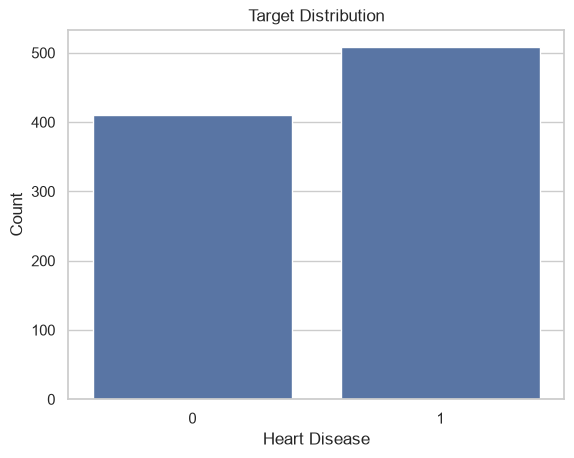

In [4]:
# Target distribution

target_counts = df_raw["HeartDisease"].value_counts().sort_index()
target_pct = df_raw["HeartDisease"].value_counts(normalize=True).sort_index().mul(100).round(2)

print("Counts:")
print(target_counts)

print("\nPercentages:")
print(target_pct)

sns.countplot(data=df_raw, x="HeartDisease")
plt.title("Target Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Count")
plt.show()

## 2. Data quality audit

Do not start feature engineering until you know:

- missing values
- duplicate rows
- impossible/suspicious values
- categorical levels
- numerical ranges

In this dataset, `Cholesterol = 0` and `RestingBP = 0` deserve investigation because they are not realistic physiological measurements.

In [5]:
# Missing values and duplicates

print("Missing values:")
display(df_raw.isna().sum().to_frame("missing"))

print("Duplicate rows:", df_raw.duplicated().sum())

Missing values:


,missing
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


Duplicate rows: 0


In [6]:
# Numerical summary

display(df_raw.describe().T)

,count,mean,std,min,25%,50%,75%,max
Age,918.000,53.511,9.433,28.000,47.000,54.000,60.000,77.000
RestingBP,918.000,132.397,18.514,0.000,120.000,130.000,140.000,200.000
Cholesterol,918.000,198.800,109.384,0.000,173.250,223.000,267.000,603.000
FastingBS,918.000,0.233,0.423,0.000,0.000,0.000,0.000,1.000
MaxHR,918.000,136.809,25.460,60.000,120.000,138.000,156.000,202.000
Oldpeak,918.000,0.887,1.067,-2.600,0.000,0.600,1.500,6.200
HeartDisease,918.000,0.553,0.497,0.000,0.000,1.000,1.000,1.000


In [7]:
# Explicitly inspect suspicious zeros

zero_check = pd.DataFrame({
    "zero_count": [
        (df_raw["RestingBP"] == 0).sum(),
        (df_raw["Cholesterol"] == 0).sum(),
        (df_raw["MaxHR"] == 0).sum(),
        (df_raw["Oldpeak"] == 0).sum()
    ]
}, index=["RestingBP", "Cholesterol", "MaxHR", "Oldpeak"])

display(zero_check)

,zero_count
RestingBP,1
Cholesterol,172
MaxHR,0
Oldpeak,368


In [8]:
# Categorical levels

categorical_cols = df_raw.select_dtypes(include=["object", "string", "category"]).columns

for col in categorical_cols:
    print(f"\n{col}")
    print(df_raw[col].value_counts())


Sex
Sex
M    725
F    193
Name: count, dtype: int64

ChestPainType
ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64

RestingECG
RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64

ExerciseAngina
ExerciseAngina
N    547
Y    371
Name: count, dtype: int64

ST_Slope
ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64


## 3. Numerical EDA

Don't only ask "what is the distribution?"

For each variable ask:

- Is it skewed?
- Are there outliers?
- Does its distribution change between `HeartDisease=0` and `HeartDisease=1`?
- Is there substantial overlap?

The overlap matters: a useful feature does **not** need to perfectly separate the classes.

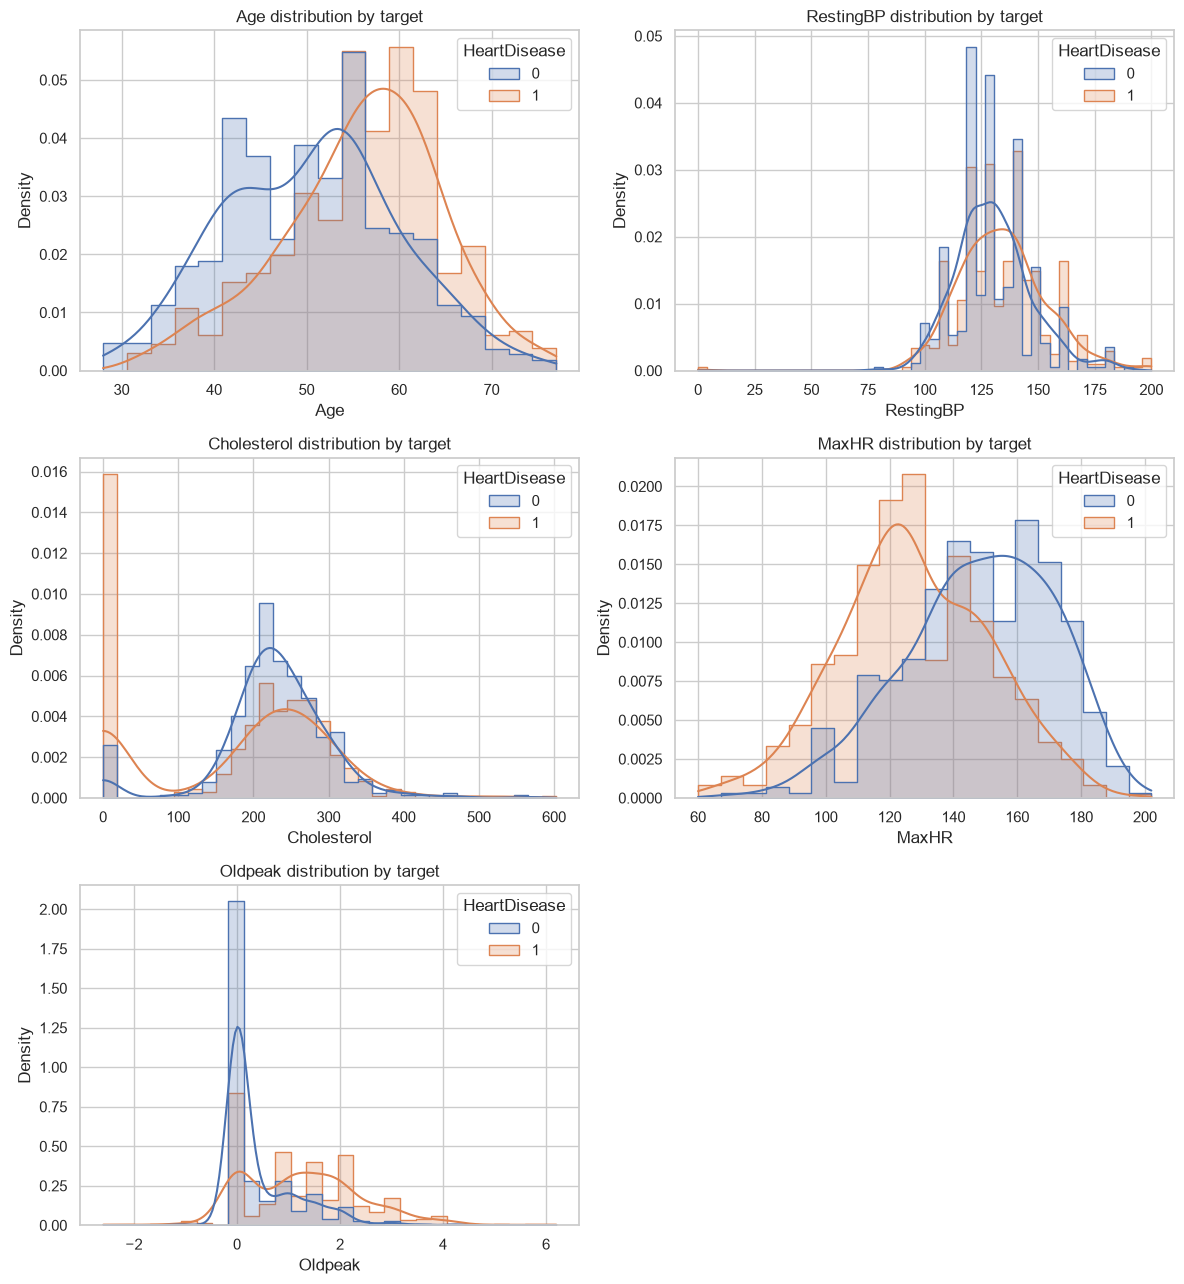

In [9]:
numerical_cols = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]

fig, axes = plt.subplots(3, 2, figsize=(12, 13))
axes = axes.ravel()

for ax, col in zip(axes, numerical_cols):
    sns.histplot(data=df_raw, x=col, hue="HeartDisease", kde=True,
                 element="step", stat="density", common_norm=False, ax=ax)
    ax.set_title(f"{col} distribution by target")

axes[-1].axis("off")
plt.tight_layout()
plt.show()

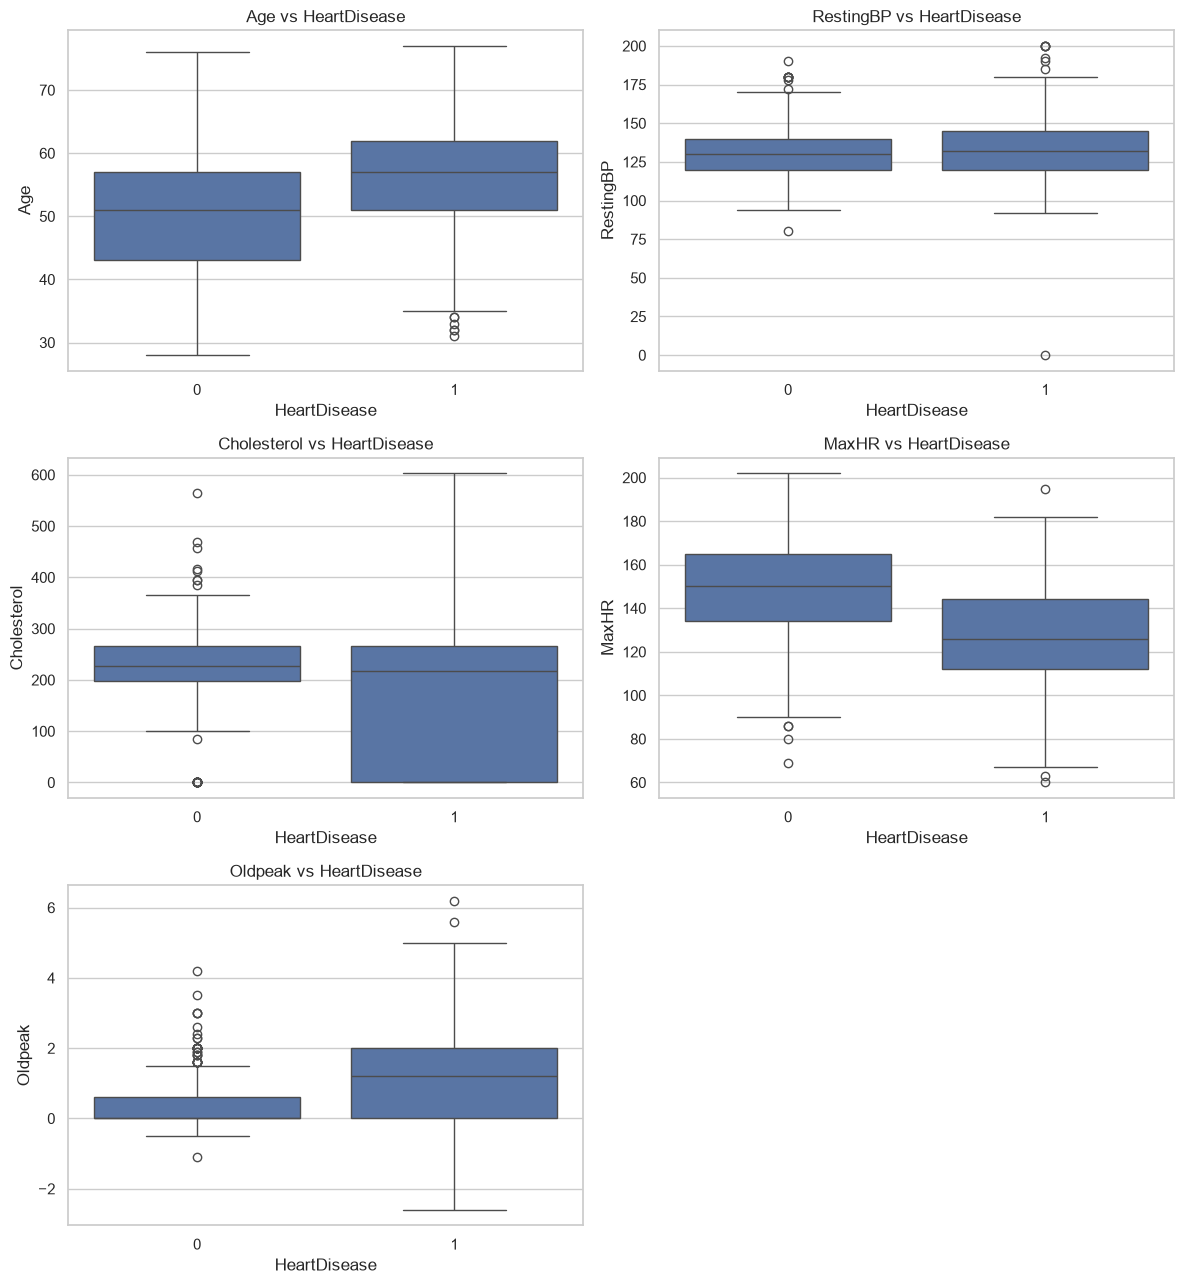

In [10]:
# Boxplots by target

fig, axes = plt.subplots(3, 2, figsize=(12, 13))
axes = axes.ravel()

for ax, col in zip(axes, numerical_cols):
    sns.boxplot(data=df_raw, x="HeartDisease", y=col, ax=ax)
    ax.set_title(f"{col} vs HeartDisease")

axes[-1].axis("off")
plt.tight_layout()
plt.show()

### Example: interpreting Oldpeak

If the `HeartDisease=1` box is shifted upward relative to `HeartDisease=0`, that is evidence of an association.

But:

> **association ≠ causation**

And if the boxes overlap, Oldpeak is not a standalone classifier. It may still be useful when combined with other variables.

In [11]:
# Numerical group statistics

display(
    df_raw.groupby("HeartDisease")[numerical_cols]
    .agg(["mean", "median", "std"])
    .T
)

HeartDisease             0       1
Age         mean    50.551  55.900
            median  51.000  57.000
            std      9.445   8.727
RestingBP   mean   130.180 134.185
            median 130.000 132.000
            std     16.500  19.829
Cholesterol mean   227.122 175.941
            median 227.000 217.000
            std     74.635 126.391
MaxHR       mean   148.151 127.656
            median 150.000 126.000
            std     23.288  23.387
Oldpeak     mean     0.408   1.274
            median   0.000   1.200
            std      0.700   1.152

## 4. Categorical EDA

For categorical variables, raw counts are not enough.

We want:

> **Within each category, what proportion has HeartDisease=1?**

This is often more informative than a simple frequency count.

In [12]:
categorical_cols = [
    "Sex",
    "ChestPainType",
    "FastingBS",
    "RestingECG",
    "ExerciseAngina",
    "ST_Slope"
]

for col in categorical_cols:
    rate = pd.crosstab(
        df_raw[col],
        df_raw["HeartDisease"],
        normalize="index"
    ).mul(100).round(2)

    print(f"\n===== {col} =====")
    display(rate)


===== Sex =====


HeartDisease,0,1
Sex,,
F,74.090,25.910
M,36.830,63.170



===== ChestPainType =====


HeartDisease,0,1
ChestPainType,,
ASY,20.970,79.030
ATA,86.130,13.870
NAP,64.530,35.470
TA,56.520,43.480



===== FastingBS =====


...

HeartDisease,0,1
RestingECG,,
LVH,43.620,56.380
Normal,48.370,51.630
ST,34.270,65.730



===== ExerciseAngina =====


HeartDisease,0,1
ExerciseAngina,,
N,64.900,35.100
Y,14.820,85.180



===== ST_Slope =====


HeartDisease,0,1
ST_Slope,,
Down,22.220,77.780
Flat,17.170,82.830
Up,80.250,19.750


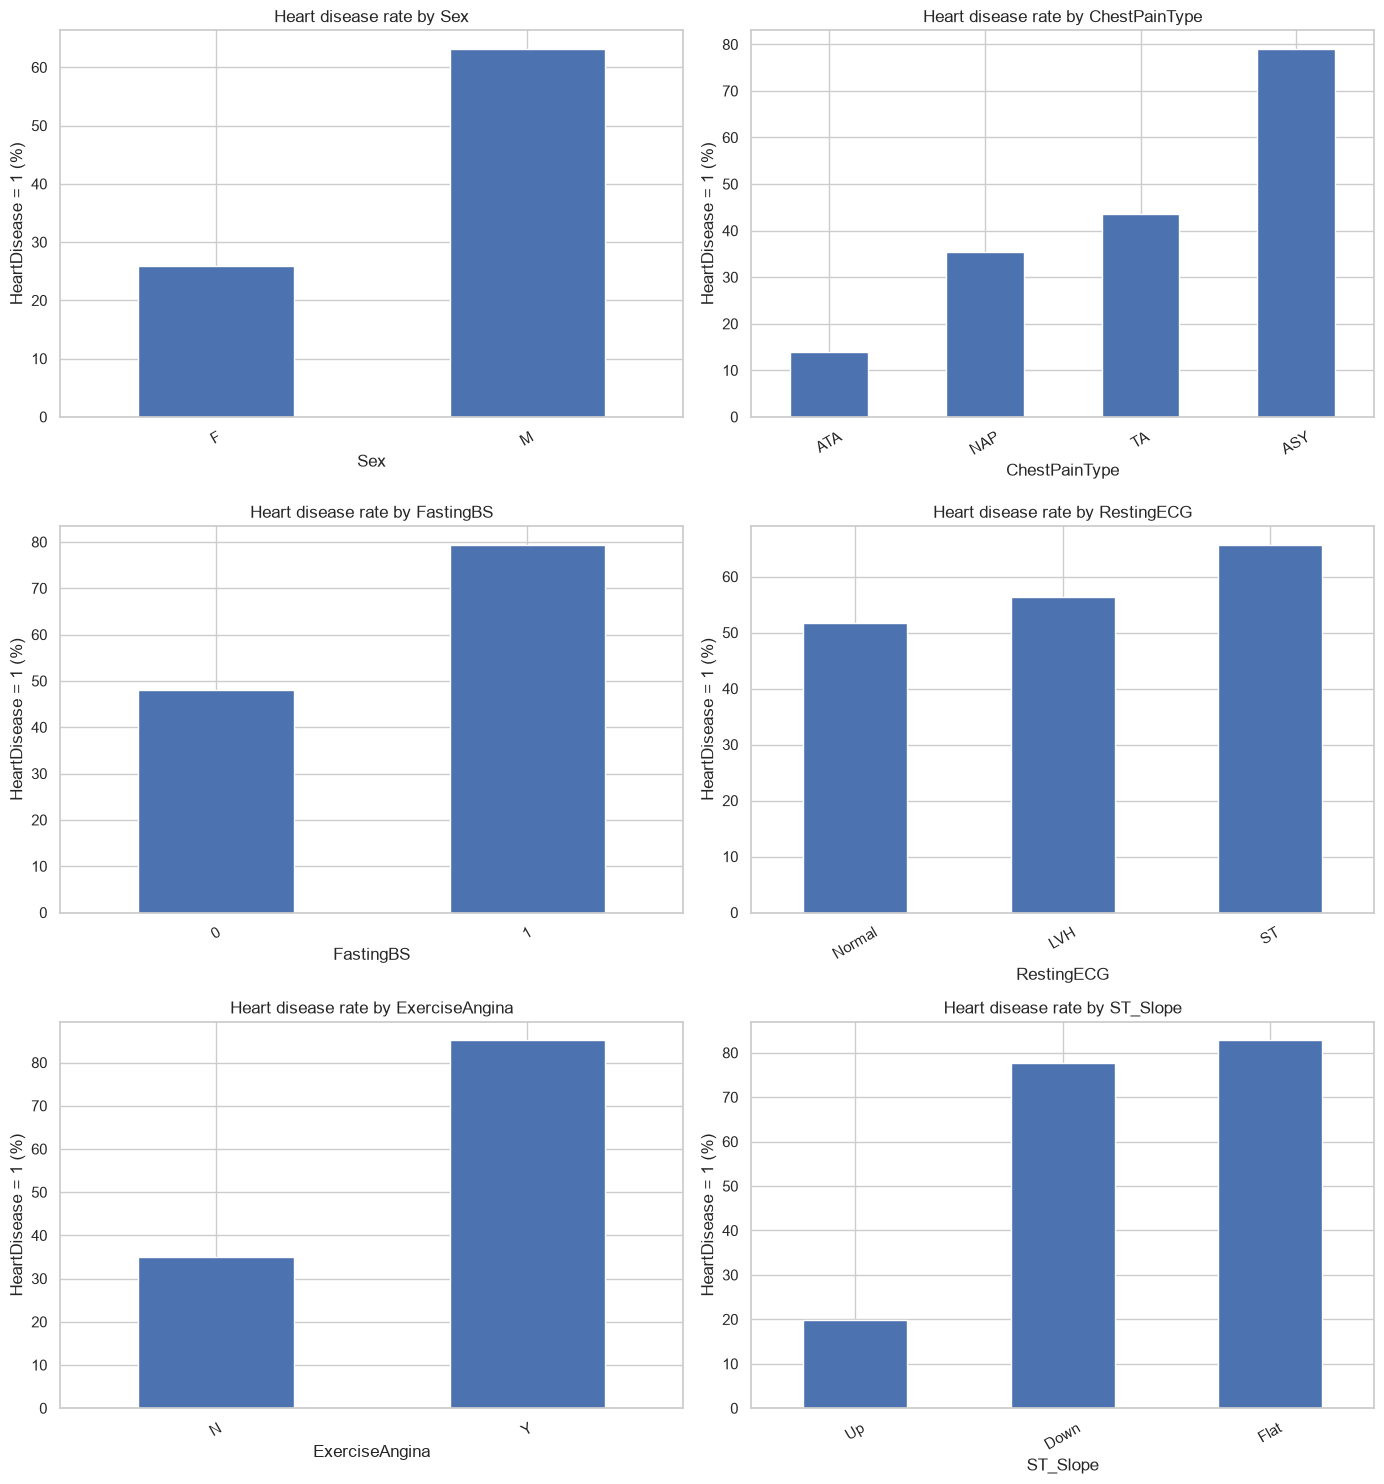

In [13]:
# Visualize target rate for each categorical feature

fig, axes = plt.subplots(3, 2, figsize=(14, 15))
axes = axes.ravel()

for ax, col in zip(axes, categorical_cols):
    rate = pd.crosstab(
        df_raw[col],
        df_raw["HeartDisease"],
        normalize="index"
    )[1].mul(100)

    rate.sort_values().plot(kind="bar", ax=ax)
    ax.set_title(f"Heart disease rate by {col}")
    ax.set_ylabel("HeartDisease = 1 (%)")
    ax.set_xlabel(col)
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

## 5. Correlation — use it as a clue, not a verdict

Pearson correlation measures **linear association**.

It does not tell us:

- causation
- nonlinear predictive power
- model importance
- whether a feature is redundant with another feature

We will use it to generate hypotheses, then validate those hypotheses with models and cross-validation.

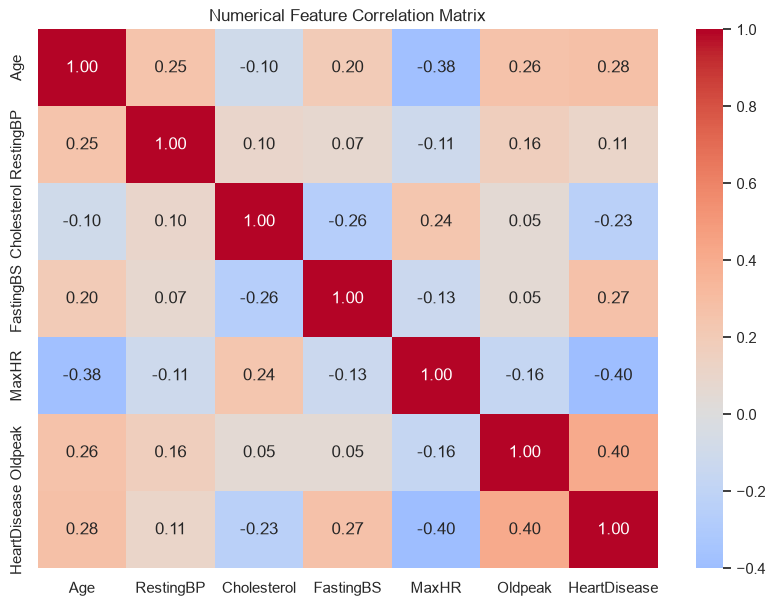

,correlation_with_HeartDisease
HeartDisease,1.000
Oldpeak,0.404
Age,0.282
FastingBS,0.267
RestingBP,0.108
Cholesterol,-0.233
MaxHR,-0.400


In [14]:
corr = df_raw.select_dtypes(include=np.number).corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Numerical Feature Correlation Matrix")
plt.show()

display(
    corr["HeartDisease"]
    .sort_values(ascending=False)
    .to_frame("correlation_with_HeartDisease")
)

## 6. Data cleaning — before splitting, but without learning from the target

The zero values in `RestingBP` and `Cholesterol` will be treated as missing measurements.

**Important:** We convert them to `NaN` here, but we do not calculate replacement means from the entire dataset.

Later, the imputer will learn its statistics **only from the training data** inside the preprocessing pipeline. This prevents data leakage.

In [15]:
df = df_raw.copy()

# Treat physiologically invalid zero measurements as missing.
df["RestingBP"] = df["RestingBP"].replace(0, np.nan)
df["Cholesterol"] = df["Cholesterol"].replace(0, np.nan)

print("RestingBP missing after cleaning:", df["RestingBP"].isna().sum())
print("Cholesterol missing after cleaning:", df["Cholesterol"].isna().sum())

RestingBP missing after cleaning: 1
Cholesterol missing after cleaning: 172


## 7. Feature engineering

Feature engineering should be driven by a relationship you can explain.

### Candidate features

**AgeGroup**
- Tests whether age bands contain a useful nonlinear pattern.

**MaxHR_Ratio**
- Compares observed maximum heart rate with a simple age-based expected value.

**MaxHR_Deficit**
- Measures the gap between expected and observed maximum heart rate.

**ST_Depression**
- Converts positive Oldpeak into a binary indicator.

**ExerciseStress**
- Combines exercise-induced angina with Oldpeak.

### Important caution

Some engineered features are derived from existing features. That means they may be redundant.

We will **test whether they actually improve the model** rather than assuming they do.

In [16]:
def engineer_features(data):
    X = data.copy()

    # Age bands
    X["AgeGroup"] = pd.cut(
        X["Age"],
        bins=[0, 40, 50, 60, 70, 100],
        labels=["<40", "40-50", "50-60", "60-70", "70+"],
        right=False
    )

    # Simple age-based expected maximum heart rate
    X["ExpectedMaxHR"] = 220 - X["Age"]

    # Relative exercise heart-rate response
    X["MaxHR_Ratio"] = X["MaxHR"] / X["ExpectedMaxHR"]

    # Difference between expected and observed maximum HR
    X["MaxHR_Deficit"] = X["ExpectedMaxHR"] - X["MaxHR"]

    # Binary indicator for positive Oldpeak
    X["ST_Depression"] = (X["Oldpeak"] > 0).astype(int)

    # Interaction: exercise-induced angina × Oldpeak
    X["ExerciseStress"] = (
        (X["ExerciseAngina"] == "Y").astype(int) * X["Oldpeak"]
    )

    # Discretized Oldpeak for an alternate representation
    X["Oldpeak_Level"] = pd.cut(
        X["Oldpeak"],
        bins=[-np.inf, 0, 1, 2, np.inf],
        labels=["Negative", "Low", "Moderate", "High"]
    )

    return X


X_full = engineer_features(df.drop(columns="HeartDisease"))
y = df["HeartDisease"].copy()

print("New shape:", X_full.shape)
display(X_full.head())

New shape: (918, 18)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,AgeGroup,ExpectedMaxHR,MaxHR_Ratio,MaxHR_Deficit,ST_Depression,ExerciseStress,Oldpeak_Level
0,40,M,ATA,140.000,289.000,0,Normal,172,N,0.000,Up,40-50,180,0.956,8,0,0.000,Negative
1,49,F,NAP,160.000,180.000,0,Normal,156,N,1.000,Flat,40-50,171,0.912,15,1,0.000,Low
2,37,M,ATA,130.000,283.000,0,ST,98,N,0.000,Up,<40,183,0.536,85,0,0.000,Negative
3,48,F,ASY,138.000,214.000,0,Normal,108,Y,1.500,Flat,40-50,172,0.628,64,1,1.500,Moderate
4,54,M,NAP,150.000,195.000,0,Normal,122,N,0.000,Up,50-60,166,0.735,44,0,0.000,Negative


## 8. Validate engineered features before trusting them

This is where we practice **data intuition**.

We don't ask:

> "Can I create a feature?"

We ask:

> "Does this feature represent a relationship that appears in the data?"

In [17]:
engineered_numeric = [
    "MaxHR_Ratio",
    "MaxHR_Deficit",
    "ST_Depression",
    "ExerciseStress"
]

display(
    X_full.groupby(y)[engineered_numeric]
    .agg(["mean", "median", "std"])
    .T
)

HeartDisease               0      1
MaxHR_Ratio    mean    0.874  0.778
               median  0.886  0.765
               std     0.128  0.139
MaxHR_Deficit  mean   21.298 36.445
               median 19.000 38.000
               std    21.600 22.856
ST_Depression  mean    0.395  0.738
               median  0.000  1.000
               std     0.489  0.440
ExerciseStress mean    0.117  0.940
               median  0.000  0.700
               std     0.423  1.107

HeartDisease,0,1
AgeGroup,,
<40,67.500,32.500
40-50,59.720,40.280
50-60,43.320,56.680
60-70,26.580,73.420
70+,29.030,70.970


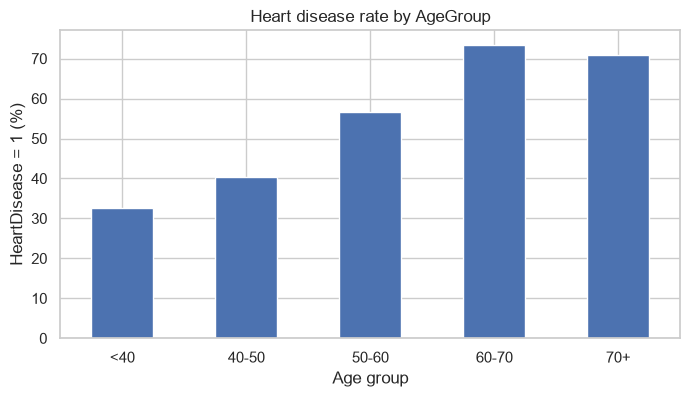

In [18]:
# Target relationship of AgeGroup

age_rate = pd.crosstab(
    X_full["AgeGroup"],
    y,
    normalize="index"
).mul(100).round(2)

display(age_rate)

age_rate[1].plot(kind="bar", figsize=(8, 4))
plt.ylabel("HeartDisease = 1 (%)")
plt.xlabel("Age group")
plt.title("Heart disease rate by AgeGroup")
plt.xticks(rotation=0)
plt.show()

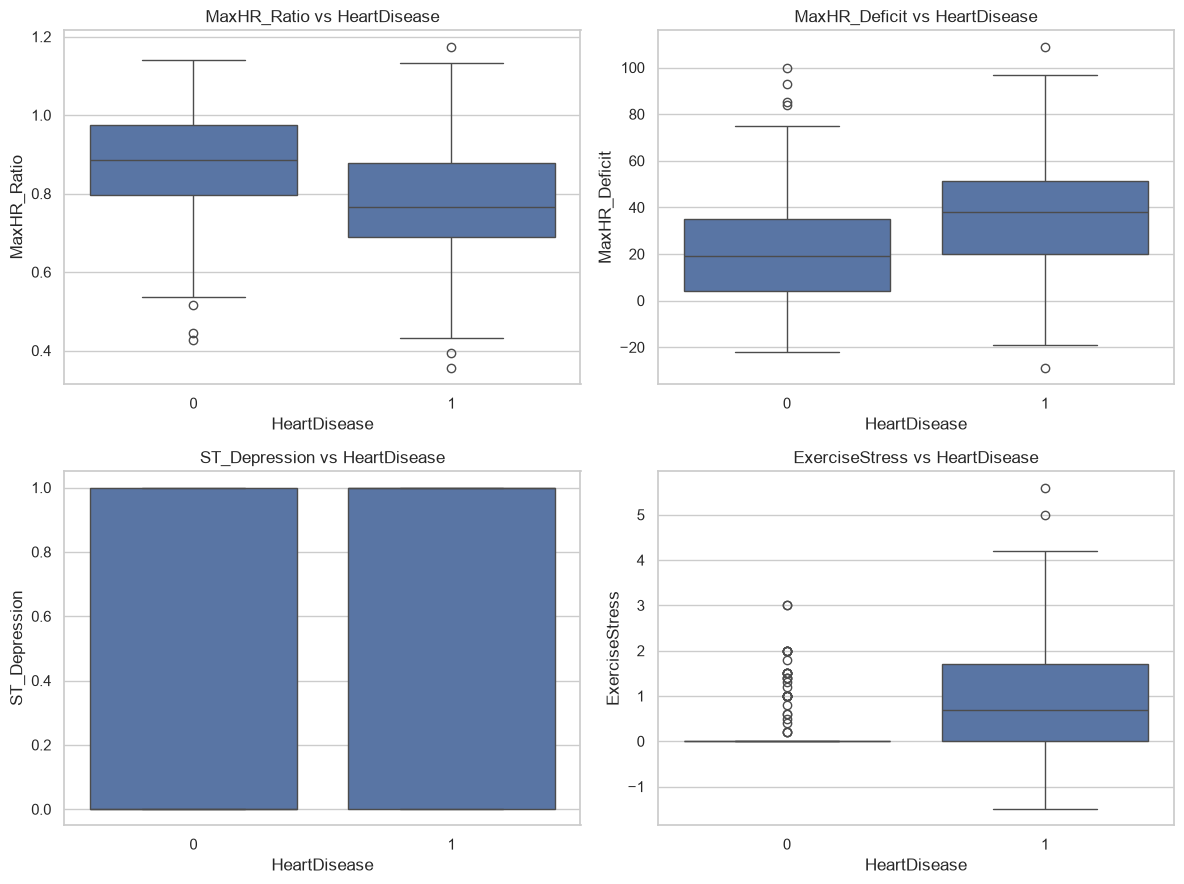

In [19]:
# Engineered numerical features vs target

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.ravel()

for ax, col in zip(axes, engineered_numeric):
    sns.boxplot(data=X_full, x=y, y=col, ax=ax)
    ax.set_title(f"{col} vs HeartDisease")

plt.tight_layout()
plt.show()

## 9. Train/test split

We split **before learning any preprocessing statistics**.

The test set is our final holdout. We should not use it to choose features, tune hyperparameters, or make preprocessing decisions.

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_full,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train distribution:")
print(y_train.value_counts(normalize=True).round(3))

X_train: (734, 18)
X_test : (184, 18)
y_train distribution:
HeartDisease
1   0.553
0   0.447
Name: proportion, dtype: float64


## 10. Preprocessing pipeline

We have mixed data:

- numerical columns → median imputation + standardization
- categorical columns → most-frequent imputation + one-hot encoding

The `ColumnTransformer` keeps this process reproducible and prevents accidental leakage.

**Note:** Scaling is important for Logistic Regression, but tree models do not require it. Using the same pipeline keeps the comparison clean.

In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_features = [
    "Age",
    "RestingBP",
    "Cholesterol",
    "MaxHR",
    "Oldpeak",
    "ExpectedMaxHR",
    "MaxHR_Ratio",
    "MaxHR_Deficit",
    "ExerciseStress"
]

categorical_features = [
    "Sex",
    "ChestPainType",
    "RestingECG",
    "ExerciseAngina",
    "ST_Slope",
    "AgeGroup",
    "Oldpeak_Level"
]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

## 11. Baseline model — Logistic Regression

Start simple.

A baseline gives us a reference point before trying more complex models.

For this classification problem, ROC-AUC is a useful primary comparison metric, while precision, recall and F1 help us understand the classification trade-offs.

In [24]:
# ============================================================
# Logistic Regression - Stratified 5-Fold Cross Validation
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
import pandas as pd

# ------------------------------------------------------------
# 1. Create Logistic Regression Pipeline
# ------------------------------------------------------------

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        LogisticRegression(
            max_iter=2000,
            random_state=RANDOM_STATE
        )
    )
])


# ------------------------------------------------------------
# 2. Stratified K-Fold Cross Validation
# ------------------------------------------------------------

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)


# ------------------------------------------------------------
# 3. Evaluation Metrics
# ------------------------------------------------------------

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}


# ------------------------------------------------------------
# 4. Perform Cross Validation
# ------------------------------------------------------------

logistic_cv = cross_validate(
    estimator=logistic_model,
    X=X_train,
    y=y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)


# ------------------------------------------------------------
# 5. Calculate Mean and Standard Deviation
# ------------------------------------------------------------

logistic_results = {}

for metric in scoring:

    scores = logistic_cv[f"test_{metric}"]

    logistic_results[metric] = (
        f"{scores.mean():.4f} ± {scores.std():.4f}"
    )


# ------------------------------------------------------------
# 6. Create Final Results DataFrame
# ------------------------------------------------------------

logistic_results_df = pd.DataFrame(
    logistic_results,
    index=["Logistic Regression"]
)


# ------------------------------------------------------------
# 7. Display Results
# ------------------------------------------------------------

print("Logistic Regression - 5-Fold Cross Validation")
print("=" * 60)

display(logistic_results_df)

Logistic Regression - 5-Fold Cross Validation


,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.8407 ± 0.0338,0.8473 ± 0.0432,0.8720 ± 0.0292,0.8586 ± 0.0271,0.9187 ± 0.0378


## 12. Compare several models

We will compare:

1. Logistic Regression — linear baseline
2. Decision Tree — nonlinear, interpretable
3. Random Forest — ensemble of trees
4. Gradient Boosting — sequential tree ensemble

The important question is not "which model sounds strongest?"

It is:

> **Which model performs consistently on unseen folds?**

In [25]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        min_samples_leaf=5,
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=400,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=2,
        random_state=RANDOM_STATE
    )
}

cv_results = []

for name, model in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1": scores["test_f1"].mean(),
        "ROC_AUC": scores["test_roc_auc"].mean(),
        "ROC_AUC_STD": scores["test_roc_auc"].std()
    })

model_results = (
    pd.DataFrame(cv_results)
    .sort_values("ROC_AUC", ascending=False)
    .reset_index(drop=True)
)

display(model_results)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,ROC_AUC_STD
0,Random Forest,0.858,0.868,0.882,0.873,0.930,0.029
1,Gradient Boosting,0.854,0.875,0.862,0.868,0.922,0.030
2,Logistic Regression,0.841,0.847,0.872,0.859,0.919,0.038
3,Decision Tree,0.809,0.843,0.808,0.824,0.871,0.040


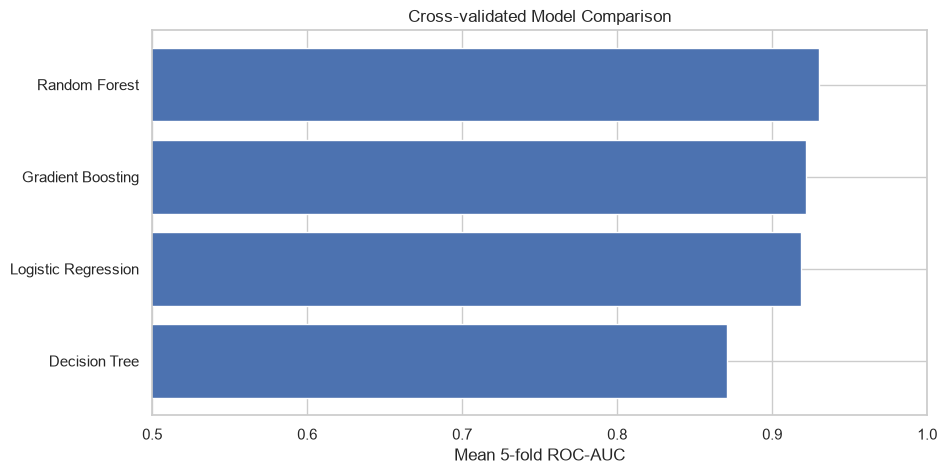

In [26]:
# Visual model comparison

plot_df = model_results.sort_values("ROC_AUC")

plt.figure(figsize=(10, 5))
plt.barh(plot_df["Model"], plot_df["ROC_AUC"])
plt.xlabel("Mean 5-fold ROC-AUC")
plt.title("Cross-validated Model Comparison")
plt.xlim(0.5, 1.0)
plt.show()

## 13. Feature information with Mutual Information

Mutual information can detect relationships that are not limited to simple Pearson correlation.

We calculate it using the **training data only**.

It should be treated as a feature-screening tool, not as the final definition of feature importance.

In [27]:
from sklearn.feature_selection import mutual_info_classif

# Fit preprocessing only on training data
X_train_transformed = preprocessor.fit_transform(X_train)

feature_names = preprocessor.get_feature_names_out()

mi_scores = mutual_info_classif(
    X_train_transformed,
    y_train,
    random_state=RANDOM_STATE
)

mi_df = (
    pd.DataFrame({
        "Feature": feature_names,
        "MutualInformation": mi_scores
    })
    .sort_values("MutualInformation", ascending=False)
)

display(mi_df.head(20))

,Feature,MutualInformation
22,cat__ST_Slope_Up,0.219
21,cat__ST_Slope_Flat,0.159
11,cat__ChestPainType_ASY,0.147
18,cat__ExerciseAngina_N,0.130
8,num__ExerciseStress,0.122
3,num__MaxHR,0.115
19,cat__ExerciseAngina_Y,0.114
4,num__Oldpeak,0.103
12,cat__ChestPainType_ATA,0.092
7,num__MaxHR_Deficit,0.072


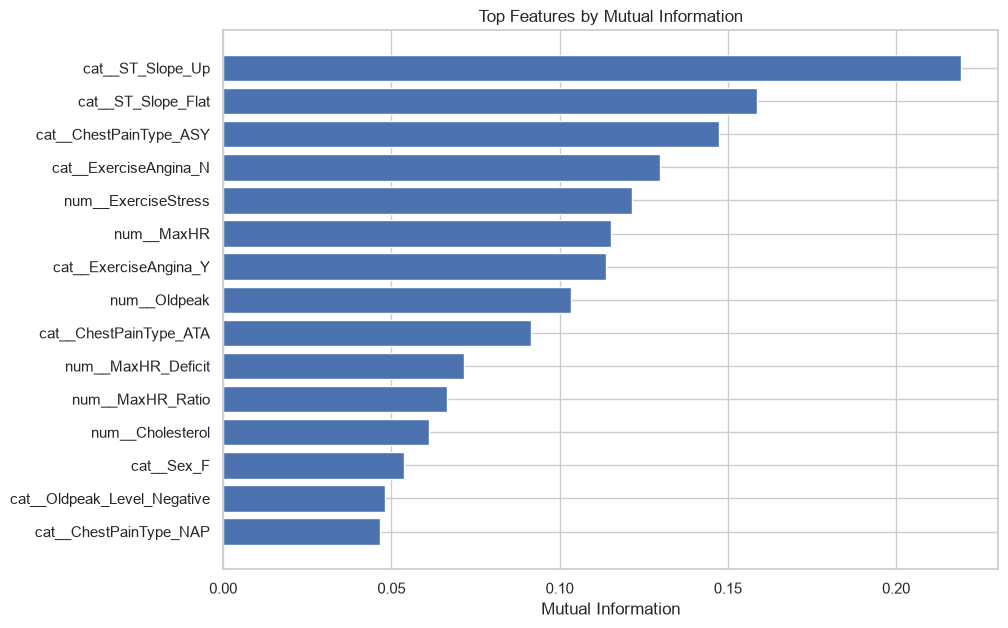

In [28]:
# Top mutual-information features

top_mi = mi_df.head(15).sort_values("MutualInformation")

plt.figure(figsize=(10, 7))
plt.barh(top_mi["Feature"], top_mi["MutualInformation"])
plt.xlabel("Mutual Information")
plt.title("Top Features by Mutual Information")
plt.show()

## 14. Feature importance / coefficients

For Logistic Regression, coefficient magnitude indicates the direction and strength of the model's learned relationship **after preprocessing**.

For Random Forest, feature importance reflects the model's impurity-based importance.

These are different concepts from correlation and mutual information.

In [29]:
# Fit Logistic Regression pipeline

final_lr = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
])

final_lr.fit(X_train, y_train)

lr_feature_names = final_lr.named_steps["preprocessor"].get_feature_names_out()
lr_coef = final_lr.named_steps["model"].coef_[0]

lr_importance = (
    pd.DataFrame({
        "Feature": lr_feature_names,
        "Coefficient": lr_coef,
        "AbsCoefficient": np.abs(lr_coef)
    })
    .sort_values("AbsCoefficient", ascending=False)
)

display(lr_importance.head(20))

,Feature,Coefficient,AbsCoefficient
22,cat__ST_Slope_Up,-1.420,1.420
11,cat__ChestPainType_ASY,1.180,1.180
21,cat__ST_Slope_Flat,1.095,1.095
9,cat__Sex_F,-0.733,0.733
10,cat__Sex_M,0.694,0.694
28,cat__Oldpeak_Level_High,0.573,0.573
12,cat__ChestPainType_ATA,-0.563,0.563
13,cat__ChestPainType_NAP,-0.544,0.544
29,cat__Oldpeak_Level_Low,-0.525,0.525
18,cat__ExerciseAngina_N,-0.357,0.357


## 15. Important experiment: original vs engineered features

This is the experiment that answers:

> **Did feature engineering actually help?**

We compare the same Logistic Regression workflow using:

### A. Original features
Only the variables present in the dataset.

### B. Engineered features
Original variables + our engineered candidates.

Do not judge the feature engineering by correlation alone. Judge it by cross-validated model performance.

In [30]:
# Original feature set
X_original = df.drop(columns="HeartDisease").copy()

X_orig_train, X_orig_test, y_orig_train, y_orig_test = train_test_split(
    X_original,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

original_numeric = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]
original_categorical = [
    "Sex", "ChestPainType", "FastingBS",
    "RestingECG", "ExerciseAngina", "ST_Slope"
]

# FastingBS is binary, so keep it numeric.
original_numeric_with_binary = original_numeric + ["FastingBS"]

original_preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), original_numeric_with_binary),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]), original_categorical)
])

baseline_lr = Pipeline([
    ("preprocessor", original_preprocessor),
    ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
])

engineered_lr = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
])

baseline_scores = cross_validate(
    baseline_lr, X_orig_train, y_orig_train,
    cv=cv, scoring=scoring, n_jobs=-1
)

engineered_scores = cross_validate(
    engineered_lr, X_train, y_train,
    cv=cv, scoring=scoring, n_jobs=-1
)

ablation_results = pd.DataFrame({
    "Original Features": [
        baseline_scores[f"test_{m}"].mean() for m in scoring
    ],
    "Original + Engineered": [
        engineered_scores[f"test_{m}"].mean() for m in scoring
    ]
}, index=scoring.keys())

display(ablation_results)

,Original Features,Original + Engineered
accuracy,0.847,0.841
precision,0.862,0.847
recall,0.867,0.872
f1,0.863,0.859
roc_auc,0.922,0.919


### How to interpret the ablation experiment

If engineered features improve ROC-AUC/F1 consistently:

> The feature engineering added useful predictive information.

If performance stays almost the same:

> The engineered features may be redundant.

If performance decreases:

> Some engineered features may be adding noise or making the model harder to generalize.

**Do not keep a feature simply because it has a high correlation with the target.**

## 16. Final model selection and untouched test evaluation

Choose the model based on cross-validation on the training set.

Only now do we evaluate once on the held-out test set.

This keeps the test set honest.

In [31]:
best_model_name = model_results.iloc[0]["Model"]
best_estimator = Pipeline([
    ("preprocessor", preprocessor),
    ("model", models[best_model_name])
])

best_estimator.fit(X_train, y_train)

test_pred = best_estimator.predict(X_test)
test_prob = best_estimator.predict_proba(X_test)[:, 1]

,Test Score
Accuracy,0.842
Precision,0.848
Recall,0.873
F1,0.860
ROC-AUC,0.919


              precision    recall  f1-score   support

           0       0.84      0.80      0.82        82
           1       0.85      0.87      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184



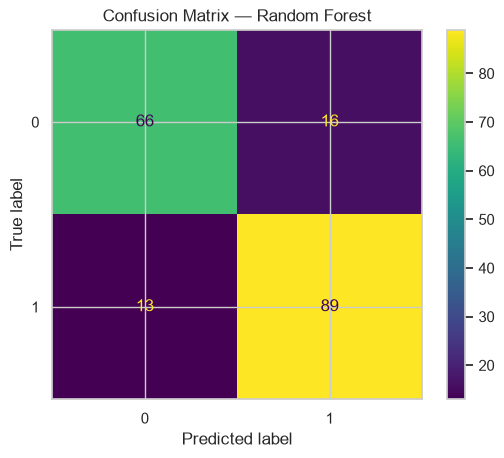

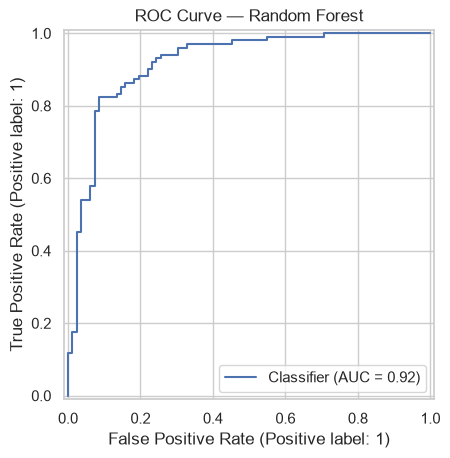

In [32]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

test_metrics = {
    "Accuracy": accuracy_score(y_test, test_pred),
    "Precision": precision_score(y_test, test_pred),
    "Recall": recall_score(y_test, test_pred),
    "F1": f1_score(y_test, test_pred),
    "ROC-AUC": roc_auc_score(y_test, test_prob)
}

display(pd.DataFrame(test_metrics, index=["Test Score"]).T)

print(classification_report(y_test, test_pred))

ConfusionMatrixDisplay.from_predictions(y_test, test_pred)
plt.title(f"Confusion Matrix — {best_model_name}")
plt.show()

RocCurveDisplay.from_predictions(y_test, test_prob)
plt.title(f"ROC Curve — {best_model_name}")
plt.show()

## 17. What you should write in the final analysis

Do not write only:

> "Random Forest achieved 90% accuracy."

Instead discuss:

### Data quality
- Which invalid values were found?
- How were they handled?
- Why was the approach chosen?

### Data intuition
- Which numerical variables differed between target classes?
- Which categorical groups showed different target rates?
- Which hypotheses were supported?

### Feature engineering
- Which features were created?
- What relationship motivated each feature?
- Did engineered features improve cross-validation?

### Modeling
- Which models were compared?
- Which metric was used for model selection?
- How stable were cross-validation scores?

### Final evaluation
- Accuracy
- Precision
- Recall
- F1
- ROC-AUC
- Confusion matrix

### Limitations
- Dataset size
- Dataset representativeness
- Possible measurement/data-quality issues
- Model is not a medical diagnostic system

## 18. Optional next level: SHAP explainability

After the core project is working, add SHAP to explain individual predictions.

A useful final project question becomes:

> **Why did the model predict a high probability for this patient?**

This is much more valuable than only reporting accuracy.

Add SHAP only after the preprocessing, cross-validation, and final evaluation are correct.

In [33]:
# Optional: check whether SHAP is installed.
# If not, install it separately in your environment.

try:
    import shap
    print("SHAP version:", shap.__version__)
except ImportError:
    print("SHAP is not installed. Install it with: pip install shap")

SHAP version: 0.52.0


# Final checklist

Before calling this project complete:

- [ ] Data quality checked
- [ ] Invalid zeros investigated and handled
- [ ] No duplicate rows
- [ ] Target distribution understood
- [ ] Numerical distributions investigated
- [ ] Categorical target rates investigated
- [ ] Feature engineering justified by hypotheses
- [ ] Train/test split performed before learned preprocessing
- [ ] Imputation fitted only on training data
- [ ] Scaling fitted only on training data
- [ ] Baseline model established
- [ ] Multiple models compared using cross-validation
- [ ] Original vs engineered features compared
- [ ] Final model evaluated once on untouched test data
- [ ] Feature importance interpreted carefully
- [ ] Limitations documented
- [ ] Optional SHAP explanation added
- [ ] Optional Streamlit application added